In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import mne

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:

# Load individual EEG 
DATA_ROOT = Path("/kaggle/input/datasets/truthisneverlinear/inner-speech-recognition/inner-speech-recognition/derivatives")

def load_eeg(subject, session):
    
    path = os.path.join(
        ROOT,
        f"sub-{subject:02d}",
        f"ses-{session:02d}",
        f"sub-{subject:02d}_ses-{session:02d}_eeg-epo.fif"
    )

    epochs = mne.read_epochs(
        path,
        preload=True,
        verbose=False
    )

    return epochs

In [3]:
eeg_path = list(DATA_ROOT.rglob("*_eeg-epo.fif"))[0]

epochs = mne.read_epochs(
    eeg_path,
    preload=True,
    verbose=False
)

X = epochs.get_data()

print("File:", eeg_path)
print("Shape:", X.shape)
print("Sampling rate:", epochs.info["sfreq"])
print("Channels:", len(epochs.ch_names))
print("Time range:", epochs.times[0], "to", epochs.times[-1])


event_path = Path(
    str(eeg_path).replace("_eeg-epo.fif", "_events.dat")
)

events = pd.read_pickle(event_path)



File: /kaggle/input/datasets/truthisneverlinear/inner-speech-recognition/inner-speech-recognition/derivatives/sub-04/ses-02/sub-04_ses-02_eeg-epo.fif
Shape: (200, 128, 1153)
Sampling rate: 256.0
Channels: 128
Time range: -0.5 to 4.0


In [4]:
X = epochs.get_data()

print("EEG shape:", X.shape)
print("Events shape:", events.shape)

assert len(X) == len(events)

print("Classes:", np.unique(events[:, 1], return_counts=True))
print("Conditions:", np.unique(events[:, 2], return_counts=True))
print("Sessions:", np.unique(events[:, 3], return_counts=True))



EEG shape: (200, 128, 1153)
Events shape: (200, 4)
Classes: (array([0, 1, 2, 3]), array([50, 50, 50, 50]))
Conditions: (array([0, 1, 2]), array([40, 80, 80]))
Sessions: (array([2]), array([200]))


In [5]:
CLASS_NAMES = {
    0: "Up",
    1: "Down",
    2: "Right",
    3: "Left"
}
# condition == 1 means Inner Speech
inner_mask = events[:, 2] == 1

X_inner = X[inner_mask]
y_inner = events[inner_mask, 1].astype(np.int64)

print("All trials:", len(X))
print("Inner-speech trials:", len(X_inner))

for label in np.unique(y_inner):
    print(
        CLASS_NAMES[label],
        np.sum(y_inner == label)
    )



All trials: 200
Inner-speech trials: 80
Up 20
Down 20
Right 20
Left 20


In [6]:
# Keep the signal 1.0s-3.5s. That's the official action interval.
times = epochs.times

action_mask = (times >= 1.0) & (times < 3.5)

X_inner = X_inner[:, :, action_mask]

print(X_inner.shape)

(80, 128, 640)


In [7]:
import plotly.graph_objects as go

trial = 0
channel = 0

signal = X_inner[trial, channel] * 1e6  # volts -> µV

time_action = times[action_mask]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=time_action,
        y=signal,
        mode="lines",
        name=epochs.ch_names[channel]
    )
)

fig.update_layout(
    title=f"Inner Speech: {CLASS_NAMES[y_inner[trial]]}",
    xaxis_title="Time (seconds)",
    yaxis_title="Amplitude (µV)"
)

fig.show()

# Exploring the EEG channels on the area of the scalp

In [8]:
import mne
import numpy as np
import pandas as pd


montage = mne.channels.make_standard_montage("biosemi128")

epochs.set_montage(
    montage,
    match_case=False,
    on_missing="warn"
)



ch_pos = epochs.get_montage().get_positions()["ch_pos"]

rows = []

for ch in epochs.ch_names:

    if ch not in ch_pos:
        continue

    x, y, z = ch_pos[ch]

    rows.append({
        "channel": ch,
        "x": x,   # left (-) / right (+)
        "y": y,   # back (-) / front (+)
        "z": z    # bottom / top
    })

channel_df = pd.DataFrame(rows)

print(channel_df.head())

  channel             x         y         z
0      A1  0.000000e+00  0.000000  0.135149
1      A2  1.109950e-18 -0.018127  0.133403
2      A3  2.272911e-18 -0.037119  0.127597
3      A4  3.252866e-18 -0.053123  0.118907
4      A5 -2.670150e-02 -0.062905  0.106141


In [9]:
# --------------------------------------------------
# 3. Assign rough scalp regions from coordinates
# --------------------------------------------------

def get_region(x, y, z):

    # Front-back classification
    if y > 0.045:
        region = "Frontal"

    elif y > 0.015:
        region = "Front-Central"

    elif y > -0.020:
        region = "Central"

    elif y > -0.050:
        region = "Parietal"

    else:
        region = "Occipital"

    # Strong lateral position → Temporal
    if abs(x) > 0.060 and -0.045 < y < 0.045:
        region = "Temporal"

    return region


channel_df["region"] = channel_df.apply(
    lambda row: get_region(
        row["x"],
        row["y"],
        row["z"]
    ),
    axis=1
)
# --------------------------------------------------
# 4. Assign hemisphere
# --------------------------------------------------

def get_hemisphere(x, threshold=0.005):

    if x < -threshold:
        return "Left"

    elif x > threshold:
        return "Right"

    else:
        return "Midline"


channel_df["hemisphere"] = channel_df["x"].apply(
    get_hemisphere
)

In [10]:
# --------------------------------------------------
# 5. View channel information
# --------------------------------------------------

channel_df[
    [
        "channel",
        "region",
        "hemisphere",
        "x",
        "y",
        "z"
    ]
].sort_values(
    ["region", "hemisphere"]
)

,channel,region,hemisphere,x,y,z
96,D1,Central,Left,-0.010655,1.466493e-02,0.133403
109,D14,Central,Left,-0.037119,-2.272911e-18,0.127597
110,D15,Central,Left,-0.017240,-5.601506e-03,0.133403
113,D18,Central,Left,-0.053123,-3.252866e-18,0.118907
0,A1,Central,Midline,0.000000,0.000000e+00,0.135149
...,...,...,...,...,...,...
58,B27,Temporal,Right,0.090295,2.933873e-02,0.036833
59,B28,Temporal,Right,0.088978,2.891062e-02,0.056645
60,B29,Temporal,Right,0.084349,2.740676e-02,0.074194
61,B30,Temporal,Right,0.073872,2.984629e-02,0.091889


In [11]:
# --------------------------------------------------
# 7. Get channels belonging to a specific region
# --------------------------------------------------

frontal_channels = channel_df[
    channel_df["region"] == "Frontal"
]["channel"].tolist()

temporal_channels = channel_df[
    channel_df["region"] == "Temporal"
]["channel"].tolist()

central_channels = channel_df[
    channel_df["region"] == "Central"
]["channel"].tolist()

parietal_channels = channel_df[
    channel_df["region"] == "Parietal"
]["channel"].tolist()

occipital_channels = channel_df[
    channel_df["region"] == "Occipital"
]["channel"].tolist()

print("Frontal:", frontal_channels)
print("Temporal:", temporal_channels)
print("Central:", central_channels)
print("Parietal:", parietal_channels)
print("Occipital:", occipital_channels)

Frontal: ['C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'C22', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31', 'C32', 'D3', 'D4', 'D5', 'D6', 'D7']
Temporal: ['B14', 'B15', 'B16', 'B17', 'B18', 'B22', 'B23', 'B24', 'B25', 'B26', 'B27', 'B28', 'B29', 'B30', 'B31', 'D8', 'D9', 'D10', 'D11', 'D12', 'D19', 'D20', 'D21', 'D22', 'D23', 'D24', 'D25', 'D26', 'D27', 'D28']
Central: ['A1', 'A2', 'B1', 'B20', 'B21', 'C1', 'D1', 'D14', 'D15', 'D18']
Parietal: ['A3', 'A6', 'B2', 'B3', 'B19', 'D16', 'D17']
Occipital: ['A4', 'A5', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'B13', 'D29', 'D30', 'D31', 'D32']


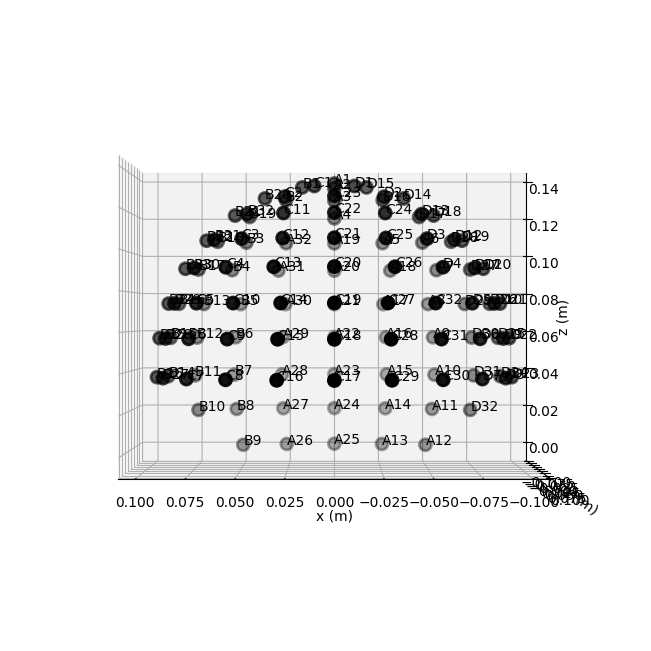

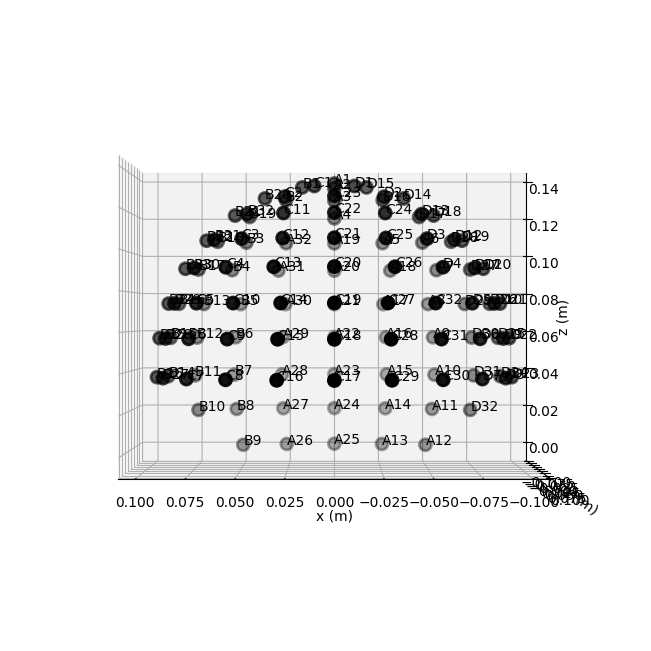

In [12]:
epochs.plot_sensors(
    kind="3d",
    show_names=True
)

In [30]:
channel_df.to_csv(
    "biosemi128_channel_regions.csv",
    index=False
)

# Create channels configs for further experiment

In [13]:
import numpy as np

# --------------------------------------------------
# 1. Get channel positions in the SAME order as X
# --------------------------------------------------

ch_pos = epochs.get_montage().get_positions()["ch_pos"]

channel_names = np.array(epochs.ch_names)

positions = np.array([
    ch_pos[ch]
    for ch in channel_names
])

print(channel_names.shape)
print(positions.shape)

# Expected:
# (128,)
# (128, 3)

(128,)
(128, 3)


In [14]:
# --------------------------------------------------
# 2. Create spatially distributed channel ranking
#    using Farthest Point Sampling
# --------------------------------------------------

def farthest_point_sampling(positions):

    n_channels = len(positions)

    # Start from electrode closest to top/center of scalp
    center_target = np.array([
        0,
        0,
        positions[:, 2].max()
    ])

    start = np.argmin(
        np.linalg.norm(
            positions - center_target,
            axis=1
        )
    )

    selected = [start]

    remaining = set(
        range(n_channels)
    )

    remaining.remove(start)

    while remaining:

        best_channel = None
        best_distance = -1

        for candidate in remaining:

            distances = np.linalg.norm(
                positions[candidate]
                - positions[selected],
                axis=1
            )

            # Distance to nearest selected electrode
            min_distance = distances.min()

            if min_distance > best_distance:

                best_distance = min_distance
                best_channel = candidate

        selected.append(
            best_channel
        )

        remaining.remove(
            best_channel
        )

    return np.array(selected)
# --------------------------------------------------
# 3. Generate full spatial ranking
# --------------------------------------------------

channel_order = farthest_point_sampling(
    positions
)

print(channel_order)

[  0  11  45  80 104  20  68 124  25  88  49 114  37  93   3  63  76  58
  71 119  55  14   5  30  90  33  86 109  27  78  41  23 127  44 100 116
   8  17  83 102  57 118  70  92 108  39  61 122 106  51 111  47  95  73
  74  34  12  53  98  66  97 112  65  50  87  16  29  60 121   9  79  81
 103  19  24  40   2  52  85 113   6  35  67  99   1   4   7  10  13  15
  18  21  22  26  28  31  36  38  42  43  46  48  54  56  59  62  64  69
  72  75  77  82  84  89  91  94  96 101 105 107 115 117 120 123 125 126
  32 110]


In [15]:
# --------------------------------------------------
# 4. Create nested channel configurations
# --------------------------------------------------

channel_configs_idx = {
    128: channel_order[:128],
    64:  channel_order[:64],
    32:  channel_order[:32],
    16:  channel_order[:16]
}

In [16]:
# --------------------------------------------------
# 5. Convert indices -> channel names
# --------------------------------------------------

channel_configs = {
    n: channel_names[idx].tolist()
    for n, idx in channel_configs_idx.items()
}

for n_channels, channels in channel_configs.items():

    print(
        f"\n{n_channels} CHANNELS"
    )

    print(channels)


128 CHANNELS
['A1', 'A12', 'B14', 'C17', 'D9', 'A21', 'C5', 'D29', 'A26', 'C25', 'B18', 'D19', 'B6', 'C30', 'A4', 'B32', 'C13', 'B27', 'C8', 'D24', 'B24', 'A15', 'A6', 'A31', 'C27', 'B2', 'C23', 'D14', 'A28', 'C15', 'B10', 'A24', 'D32', 'B13', 'D5', 'D21', 'A9', 'A18', 'C20', 'D7', 'B26', 'D23', 'C7', 'C29', 'D13', 'B8', 'B30', 'D27', 'D11', 'B20', 'D16', 'B16', 'C32', 'C10', 'C11', 'B3', 'A13', 'B22', 'D3', 'C3', 'D2', 'D17', 'C2', 'B19', 'C24', 'A17', 'A30', 'B29', 'D26', 'A10', 'C16', 'C18', 'D8', 'A20', 'A25', 'B9', 'A3', 'B21', 'C22', 'D18', 'A7', 'B4', 'C4', 'D4', 'A2', 'A5', 'A8', 'A11', 'A14', 'A16', 'A19', 'A22', 'A23', 'A27', 'A29', 'A32', 'B5', 'B7', 'B11', 'B12', 'B15', 'B17', 'B23', 'B25', 'B28', 'B31', 'C1', 'C6', 'C9', 'C12', 'C14', 'C19', 'C21', 'C26', 'C28', 'C31', 'D1', 'D6', 'D10', 'D12', 'D20', 'D22', 'D25', 'D28', 'D30', 'D31', 'B1', 'D15']

64 CHANNELS
['A1', 'A12', 'B14', 'C17', 'D9', 'A21', 'C5', 'D29', 'A26', 'C25', 'B18', 'D19', 'B6', 'C30', 'A4', 'B32', 'C13

In [17]:
assert set(channel_configs[16]).issubset(
    channel_configs[32]
)

assert set(channel_configs[32]).issubset(
    channel_configs[64]
)

assert set(channel_configs[64]).issubset(
    channel_configs[128]
)

print("All configurations are nested correctly.")

All configurations are nested correctly.


In [18]:
for n_channels, channels in channel_configs.items():

    subset = channel_df[
        channel_df["channel"].isin(
            channels
        )
    ]

    print(
        f"\n===== {n_channels} channels ====="
    )

    print(
        subset.groupby(
            ["region", "hemisphere"]
        ).size()
    )


===== 128 channels =====
region         hemisphere
Central        Left           4
               Midline        2
               Right          4
Front-Central  Left           2
               Midline        1
               Right          2
Frontal        Left          14
               Midline        6
               Right         14
Occipital      Left          17
               Midline        8
               Right         17
Parietal       Left           3
               Midline        1
               Right          3
Temporal       Left          15
               Right         15
dtype: int64

===== 64 channels =====
region         hemisphere
Central        Left          1
               Midline       1
               Right         1
Front-Central  Left          2
               Midline       1
               Right         2
Frontal        Left          8
               Midline       2
               Right         8
Occipital      Left          7
               Midline       3

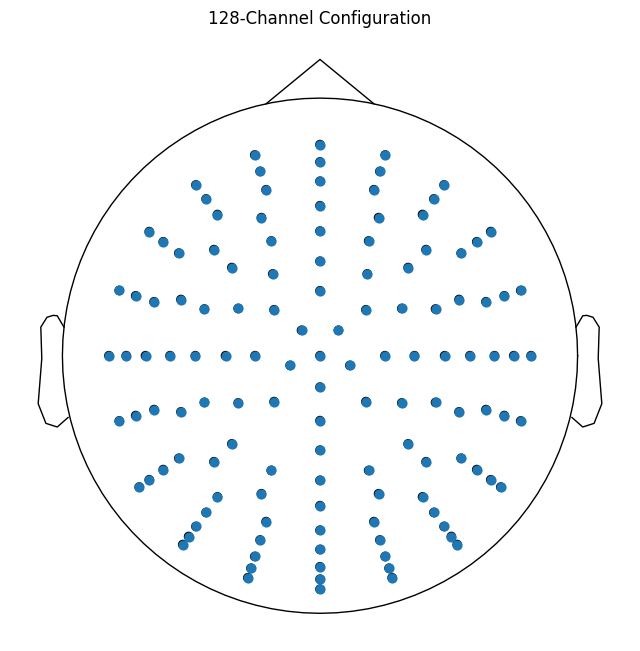

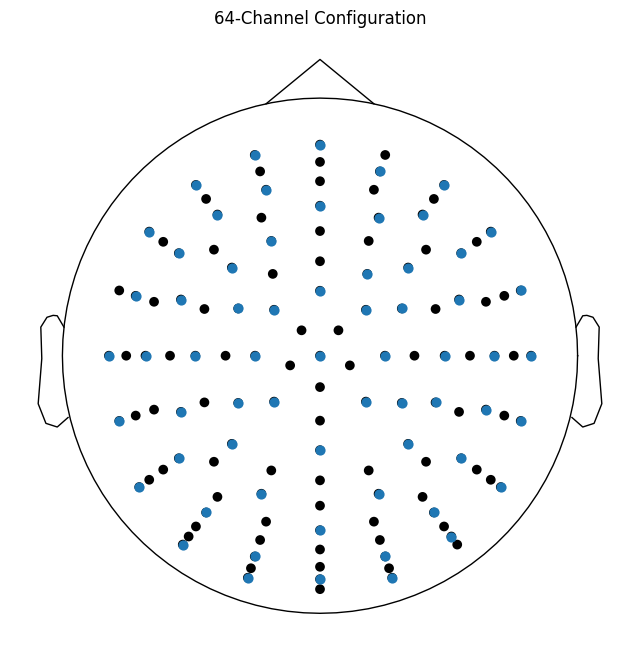

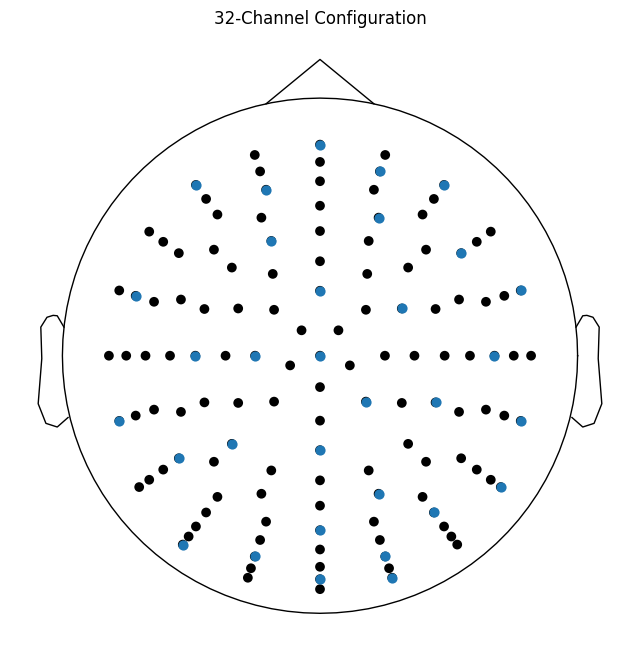

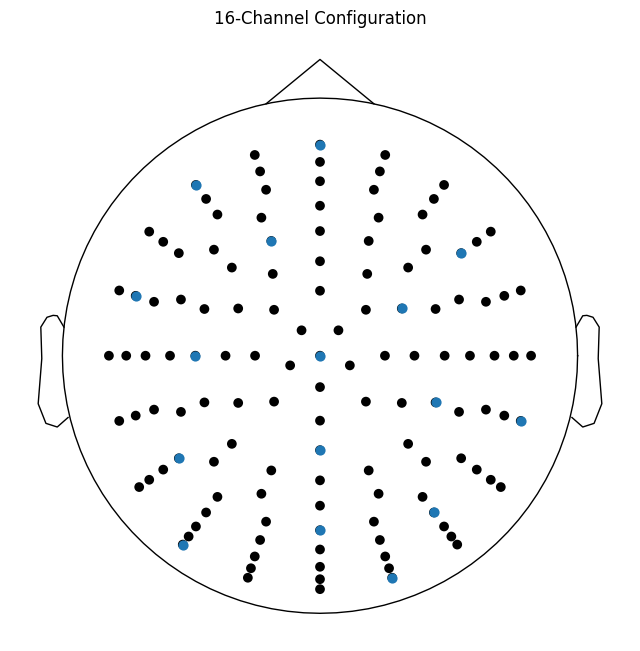

In [19]:
import matplotlib.pyplot as plt
import mne

for n_channels, channels in channel_configs.items():

    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    picks = [
        epochs.ch_names.index(ch)
        for ch in channels
    ]

    mne.viz.plot_sensors(
        epochs.info,
        kind="topomap",
        ch_type="eeg",
        show_names=False,
        axes=ax,
        show=False
    )

    xy = mne.channels.layout._find_topomap_coords(
        epochs.info,
        picks=picks
    )

    ax.scatter(
        xy[:, 0],
        xy[:, 1],
        s=40
    )

    ax.set_title(
        f"{n_channels}-Channel Configuration"
    )

    plt.show()

In [20]:
X_configs = {
    n: X[:, idx, :]
    for n, idx
    in channel_configs_idx.items()
}

for n, data in X_configs.items():
    print(n, data.shape)

128 (200, 128, 1153)
64 (200, 64, 1153)
32 (200, 32, 1153)
16 (200, 16, 1153)


In [21]:
np.save(
    "channel_configs_idx.npy",
    channel_configs_idx,
    allow_pickle=True
)

np.save(
    "channel_configs_names.npy",
    channel_configs,
    allow_pickle=True
)

# Load all subjects

In [9]:
all_X = []
all_y = []
all_subjects = []
all_sessions = []

eeg_files = sorted(
    DATA_ROOT.rglob("*_eeg-epo.fif")
)

print("Number of EEG files:", len(eeg_files))


Number of EEG files: 30


In [10]:
for file_number, eeg_path in enumerate(eeg_files):

    # -----------------------
    # Load EEG
    # -----------------------
    epochs = mne.read_epochs(
        eeg_path,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()

    # -----------------------
    # Load events
    # -----------------------
    event_path = Path(
        str(eeg_path).replace(
            "_eeg-epo.fif",
            "_events.dat"
        )
    )

    events = pd.read_pickle(event_path)
    events = np.asarray(events)

    assert len(X) == len(events)

    # -----------------------
    # Subject and session IDs
    # -----------------------
    subject = int(
        re.search(
            r"sub-(\d+)",
            str(eeg_path)
        ).group(1)
    )
    session_match = re.search(r"ses-([^/\_]+)", str(eeg_path))
    session_token = (
        session_match.group(1)
        if session_match is not None
        else f"file-{file_number:03d}"
    )
    session_id = f"sub-{subject:02d}_ses-{session_token}"

    # -----------------------
    # Inner Speech only
    # -----------------------
    inner_mask = events[:, 2] == 1

    X = X[inner_mask]
    y = events[inner_mask, 1].astype(np.int64)

    # -----------------------
    # Official action interval
    # -----------------------
    times = epochs.times

    action_mask = (
        (times >= 1.0) &
        (times < 3.5)
    )

    X = X[:, :, action_mask]

    # -----------------------
    # Save
    # -----------------------
    all_X.append(X)
    all_y.append(y)

    all_subjects.append(
        np.full(
            len(X),
            subject,
            dtype=np.int64
        )
    )
    all_sessions.append(
        np.full(
            len(X),
            session_id,
            dtype=object
        )
    )


In [11]:
X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)
subjects = np.concatenate(all_subjects, axis=0)
sessions = np.concatenate(all_sessions, axis=0)

print("X:", X.shape)
print("y:", y.shape)
print("subjects:", subjects.shape)
print("sessions:", sessions.shape)
print("Unique sessions:", len(np.unique(sessions)))


X: (2236, 128, 640)
y: (2236,)
subjects: (2236,)


In [12]:
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("\nClasses:")
for label in range(4):
    print(
        CLASS_NAMES[label],
        np.sum(y == label)
    )

print("\nSubjects:")
for subject in np.unique(subjects):
    print(
        f"Subject {subject}:",
        np.sum(subjects == subject)
    )

NaN: 0
Inf: 0

Classes:
Up 559
Down 559
Right 559
Left 559

Subjects:
Subject 1: 200
Subject 2: 240
Subject 3: 180
Subject 4: 240
Subject 5: 240
Subject 6: 216
Subject 7: 240
Subject 8: 200
Subject 9: 240
Subject 10: 240


# Machine learning approach

In [13]:
# Split by subject

train_subjects = [1, 2, 3, 4, 5, 6, 7]
val_subjects   = [8]
test_subjects  = [9, 10]

train_mask = np.isin(subjects, train_subjects)
val_mask   = np.isin(subjects, val_subjects)
test_mask  = np.isin(subjects, test_subjects)

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1556, 128, 640)
(200, 128, 640)
(480, 128, 640)


In [14]:
# Using welch method 
from scipy.signal import welch
def extract_bandpower_features(X, fs):

    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta":  (13, 30),
        "gamma": (30, 45)
    }

    all_features = []

    for trial in X:

        # trial:
        # [channels, time]

        freqs, psd = welch(
            trial,
            fs=fs,
            nperseg=min(256, trial.shape[-1]),
            axis=-1
        )

        trial_features = []

        for low, high in bands.values():

            mask = (
                (freqs >= low) &
                (freqs < high)
            )

            band_power = psd[:, mask].mean(axis=1)

            # Log-transform power
            band_power = np.log(
                band_power + 1e-12
            )

            trial_features.append(
                band_power
            )

        # [5 bands, 128 channels]
        trial_features = np.array(
            trial_features
        )

        # Flatten:
        # 5 × 128 = 640 features
        trial_features = trial_features.flatten()

        all_features.append(
            trial_features
        )

    return np.array(all_features)

In [15]:
fs = epochs.info["sfreq"] # Sampling rate

print(fs)

X_train_ml = extract_bandpower_features(
    X_train,
    fs
)

X_val_ml = extract_bandpower_features(
    X_val,
    fs
)

X_test_ml = extract_bandpower_features(
    X_test,
    fs
)

print(X_train_ml.shape)

256.0
(1556, 640)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_ml = scaler.fit_transform(
    X_train_ml
)

X_val_ml = scaler.transform(
    X_val_ml
)

X_test_ml = scaler.transform(
    X_test_ml
)

In [17]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

svm.fit(
    X_train_ml,
    y_train
)

SVC()

In [18]:
from sklearn.metrics import accuracy_score, f1_score

val_pred = svm.predict(
    X_val_ml
)

print(
    "Val Accuracy:",
    accuracy_score(
        y_val,
        val_pred
    )
)

print(
    "Val Macro F1:",
    f1_score(
        y_val,
        val_pred,
        average="macro"
    )
)
test_pred = svm.predict(
    X_test_ml
)

print(
    "Test Accuracy:",
    accuracy_score(
        y_test,
        test_pred
    )
)

print(
    "Test Macro F1:",
    f1_score(
        y_test,
        test_pred,
        average="macro"
    )
)

Val Accuracy: 0.27
Val Macro F1: 0.252244494635799
Test Accuracy: 0.25625
Test Macro F1: 0.24393656201362182


# Deep learning baseline


In [19]:
mean = X_train.mean(
    axis=(0, 2),
    keepdims=True
)

std = X_train.std(
    axis=(0, 2),
    keepdims=True
)

std = np.maximum(
    std,
    1e-8
)

X_train_dl = (
    X_train - mean
) / std

X_val_dl = (
    X_val - mean
) / std

X_test_dl = (
    X_test - mean
) / std

In [20]:
print(X_train_dl.shape)

print(
    X_train_dl.mean(),
    X_train_dl.std()
)

(1556, 128, 640)
5.5254287292398535e-17 0.9999999999999976


In [21]:
import torch
from torch.utils.data import Dataset, DataLoader


class EEGDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

train_dataset = EEGDataset(
    X_train_dl,
    y_train
)

val_dataset = EEGDataset(
    X_val_dl,
    y_val
)

test_dataset = EEGDataset(
    X_test_dl,
    y_test
)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [22]:
# EEGNet style baseline
import torch.nn as nn


class EEGNet(nn.Module):

    def __init__(
        self,
        n_channels,
        n_classes=4,
        dropout=0.5
    ):

        super().__init__()

        F1 = 8
        D = 2
        F2 = F1 * D

        # Temporal filtering
        self.temporal = nn.Sequential(

            nn.Conv2d(
                1,
                F1,
                kernel_size=(1, 64),
                padding=(0, 32),
                bias=False
            ),

            nn.BatchNorm2d(F1)
        )

        # Spatial filtering across EEG channels
        self.spatial = nn.Sequential(

            nn.Conv2d(
                F1,
                F1 * D,
                kernel_size=(n_channels, 1),
                groups=F1,
                bias=False
            ),

            nn.BatchNorm2d(F1 * D),

            nn.ELU(),

            nn.AvgPool2d(
                kernel_size=(1, 4)
            ),

            nn.Dropout(dropout)
        )

        # Separable temporal convolution
        self.separable = nn.Sequential(

            nn.Conv2d(
                F2,
                F2,
                kernel_size=(1, 16),
                padding=(0, 8),
                groups=F2,
                bias=False
            ),

            nn.Conv2d(
                F2,
                F2,
                kernel_size=(1, 1),
                bias=False
            ),

            nn.BatchNorm2d(F2),

            nn.ELU(),

            nn.AvgPool2d(
                kernel_size=(1, 8)
            ),

            nn.Dropout(dropout)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Linear(
            F2,
            n_classes
        )

    def forward(self, x):

        # [B, channels, time]
        # ->
        # [B, 1, channels, time]

        x = x.unsqueeze(1)

        x = self.temporal(x)

        x = self.spatial(x)

        x = self.separable(x)

        x = self.pool(x)

        x = x.flatten(1)

        return self.classifier(x)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = EEGNet(
    n_channels=X_train_dl.shape[1],
    n_classes=4
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [31]:
from tqdm import tqdm

def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)

        pred = logits.argmax(dim=1)

        correct += (
            pred == y_batch
        ).sum().item()

        total += len(y_batch)

    return (
        total_loss / total,
        correct / total
    )

In [32]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    total = 0

    predictions = []
    labels = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        total_loss += loss.item() * len(y_batch)
        total += len(y_batch)

        pred = logits.argmax(dim=1)

        predictions.extend(
            pred.cpu().numpy()
        )

        labels.extend(
            y_batch.cpu().numpy()
        )

    predictions = np.array(predictions)
    labels = np.array(labels)

    accuracy = (
        predictions == labels
    ).mean()

    return (
        total_loss / total,
        accuracy,
        labels,
        predictions
    )

In [33]:
from tqdm import tqdm

EPOCHS = 50
best_val = 0

pbar = tqdm(
    range(EPOCHS),
    desc="Training EEGNet"
)

for epoch in pbar:

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    if val_acc > best_val:

        best_val = val_acc

        torch.save(
            model.state_dict(),
            "best_eegnet.pt"
        )

    pbar.set_postfix(
        train_acc=f"{train_acc:.3f}",
        val_acc=f"{val_acc:.3f}",
        best=f"{best_val:.3f}",
        loss=f"{train_loss:.3f}"
    )

Training EEGNet: 100%|██████████| 50/50 [02:15<00:00,  2.70s/it, best=0.265, loss=0.872, train_acc=0.642, val_acc=0.225]


# Recommended three-pipeline experiments

This section implements the selected final design across the fixed **128 / 64 / 32 / 16** nested channel configurations:

1. **Paper-inspired classical model:** rich time, frequency, and wavelet features → fold-local variance filtering → approximate MRMR → fold-local standardization → tuned SVM.
2. **Improved scratch model:** EEGNet with training-only normalization, mild training-only augmentation, AdamW, cosine scheduling, early stopping, and repeated seeds.
3. **Pretrained transfer model:** LaBraM-Base with a fixed geometry-derived projection from the BioSemi montage to LaBraM's canonical 128-position montage, followed by linear probing, partial fine-tuning, and full fine-tuning.

The default development split remains subjects 1–7 / subject 8 / subjects 9–10. Test data never controls preprocessing, feature selection, hyperparameters, learning-rate schedules, or early stopping. Optional functions at the end run rigorous LOSO and paper-comparable subject-specific analyses.

**Run modes:** `quick` uses one deep-learning seed and a compact SVM grid. Change `RUN_MODE` to `final` for five seeds and the complete search. LaBraM stays opt-in because its checkpoint must be downloaded once.


In [ ]:
import copy
import hashlib
import json
import math
import random
import warnings
from fractions import Fraction

import pywt
from joblib import Memory
from scipy.signal import resample_poly, welch
from scipy.stats import kurtosis, skew
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


RUN_MODE = "quick"  # Change to "final" for the report-quality experiment.
if RUN_MODE not in {"quick", "final"}:
    raise ValueError("RUN_MODE must be 'quick' or 'final'.")

CHANNEL_COUNTS = (128, 64, 32, 16)
FINAL_SEEDS = (13, 42, 101, 202, 999)
ACTIVE_DEEP_SEEDS = (42,) if RUN_MODE == "quick" else FINAL_SEEDS

RUN_DEVELOPMENT_RICH_SVM = True
RUN_DEVELOPMENT_EEGNET = True
RUN_DEVELOPMENT_LABRAM = False
RUN_LABRAM_RANDOM_CONTROL = False

RESULTS_DIR = Path("results_recommended")
CHECKPOINT_DIR = Path("checkpoints_recommended")
CACHE_DIR = RESULTS_DIR / "cache"
for directory in (RESULTS_DIR, CHECKPOINT_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
SKLEARN_MEMORY = Memory(CACHE_DIR / "sklearn_pipeline", verbose=0)

DEV_SPLIT = {
    "train": (1, 2, 3, 4, 5, 6, 7),
    "val": (8,),
    "test": (9, 10),
}

EXPERIMENT_ROWS = {}
PREDICTION_FRAMES = {}


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def validate_subject_split(split):
    groups = [set(split[name]) for name in ("train", "val", "test")]
    assert all(groups), "Train, validation, and test groups must be non-empty."
    assert not (groups[0] & groups[1] or groups[0] & groups[2] or groups[1] & groups[2])
    assert set.union(*groups).issubset(set(np.unique(subjects).tolist()))


def subject_split_masks(split):
    validate_subject_split(split)
    return {
        name: np.isin(subjects, split[name])
        for name in ("train", "val", "test")
    }


def channel_config_hash(n_channels):
    payload = json.dumps(channel_configs[n_channels], separators=(",", ":"))
    return hashlib.sha256(payload.encode()).hexdigest()[:12]


def classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def store_predictions(protocol, fold, model_name, n_channels, partition, mask, y_pred, seed):
    key = (protocol, fold, model_name, n_channels, partition, seed)
    PREDICTION_FRAMES[key] = pd.DataFrame({
        "protocol": protocol,
        "fold": fold,
        "model": model_name,
        "n_channels": n_channels,
        "partition": partition,
        "seed": seed,
        "subject": subjects[mask],
        "session": sessions[mask],
        "y_true": y[mask],
        "y_pred": np.asarray(y_pred),
    })


def store_result(
    protocol,
    fold,
    model_name,
    n_channels,
    split,
    val_metrics,
    test_metrics,
    seed,
    best_epoch=None,
    config_extra=None,
):
    row = {
        "protocol": protocol,
        "fold": fold,
        "model": model_name,
        "n_channels": n_channels,
        "channel_config_hash": channel_config_hash(n_channels),
        "train_subjects": ",".join(map(str, split["train"])),
        "val_subjects": ",".join(map(str, split["val"])),
        "test_subjects": ",".join(map(str, split["test"])),
        "input_sfreq": float(fs),
        "time_start_s": 1.0,
        "time_stop_s": 3.5,
        "seed": seed,
        "best_epoch": best_epoch,
        **{f"val_{key}": value for key, value in val_metrics.items()},
        **{f"test_{key}": value for key, value in test_metrics.items()},
    }
    if config_extra:
        row.update(config_extra)
    EXPERIMENT_ROWS[(protocol, fold, model_name, n_channels, seed)] = row
    return row


experiment_info = mne.create_info(
    ch_names=channel_names.tolist(),
    sfreq=float(fs),
    ch_types="eeg",
)
experiment_info.set_montage(
    mne.channels.make_standard_montage("biosemi128"),
    match_case=False,
    on_missing="raise",
)

assert X.ndim == 3 and X.shape[1] == 128
assert len(X) == len(y) == len(subjects) == len(sessions)
assert np.isfinite(X).all()
assert set(CHANNEL_COUNTS) == set(channel_configs_idx)
assert all(len(np.unique(channel_configs_idx[n])) == n for n in CHANNEL_COUNTS)
assert set(channel_configs_idx[16]).issubset(channel_configs_idx[32])
assert set(channel_configs_idx[32]).issubset(channel_configs_idx[64])
assert set(channel_configs_idx[64]).issubset(channel_configs_idx[128])
validate_subject_split(DEV_SPLIT)

set_all_seeds(42)
print("Run mode:", RUN_MODE)
print("Device:", device)
print("Deep-learning seeds:", ACTIVE_DEEP_SEEDS)
print("Development split:", DEV_SPLIT)
print("Channel hashes:", {n: channel_config_hash(n) for n in CHANNEL_COUNTS})


## Pipeline 1 — rich features + fold-safe MRMR + tuned SVM

The feature bank intentionally follows the paper's categories without claiming an exact reproduction of its unavailable supplementary feature list. It includes time-domain statistics and Hjorth parameters, absolute and relative Welch bandpower, spectral descriptors, and multi-resolution wavelet statistics.

`ApproxMRMR` first keeps the most label-relevant candidates using mutual information and then greedily penalizes correlated selections. Crucially, variance filtering, MRMR, scaling, and SVM tuning live inside the cross-validation pipeline, so validation or test trials cannot influence feature selection.


In [ ]:
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}


def extract_rich_feature_tensor(data, sfreq):
    # Return [trial, channel, feature] and per-channel feature names.
    eps = 1e-12
    trial_features = []
    feature_names = None

    for trial in tqdm(data, desc="Rich EEG features", leave=False):
        values = []
        names = []

        first_diff = np.diff(trial, axis=-1)
        second_diff = np.diff(first_diff, axis=-1)
        activity = np.var(trial, axis=-1)
        diff_activity = np.var(first_diff, axis=-1)
        second_activity = np.var(second_diff, axis=-1)
        mobility = np.sqrt(diff_activity / (activity + eps))
        complexity = (
            np.sqrt(second_activity / (diff_activity + eps)) /
            (mobility + eps)
        )

        time_values = [
            np.mean(trial, axis=-1),
            np.std(trial, axis=-1),
            np.sqrt(np.mean(trial ** 2, axis=-1)),
            np.ptp(trial, axis=-1),
            skew(trial, axis=-1, bias=False),
            kurtosis(trial, axis=-1, fisher=True, bias=False),
            np.mean(np.abs(first_diff), axis=-1),
            np.mean(np.diff(np.signbit(trial), axis=-1) != 0, axis=-1),
            activity,
            mobility,
            complexity,
        ]
        time_names = [
            "mean", "std", "rms", "peak_to_peak", "skewness",
            "kurtosis", "line_length", "zero_crossing_rate",
            "hjorth_activity", "hjorth_mobility", "hjorth_complexity",
        ]
        values.extend(time_values)
        names.extend(time_names)

        frequencies, psd = welch(
            trial,
            fs=sfreq,
            nperseg=min(256, trial.shape[-1]),
            axis=-1,
        )
        analysis_mask = (frequencies >= 1) & (frequencies <= 45)
        analysis_psd = psd[:, analysis_mask]
        analysis_freqs = frequencies[analysis_mask]
        total_power = np.trapz(analysis_psd, analysis_freqs, axis=-1) + eps

        for band_name, (low, high) in BANDS.items():
            band_mask = (frequencies >= low) & (frequencies < high)
            band_power = np.trapz(psd[:, band_mask], frequencies[band_mask], axis=-1)
            values.extend([np.log(band_power + eps), band_power / total_power])
            names.extend([f"log_power_{band_name}", f"relative_power_{band_name}"])

        probability = analysis_psd / (analysis_psd.sum(axis=-1, keepdims=True) + eps)
        spectral_entropy = -np.sum(probability * np.log(probability + eps), axis=-1)
        spectral_entropy /= np.log(max(2, analysis_psd.shape[-1]))
        spectral_centroid = (
            (analysis_psd * analysis_freqs[None, :]).sum(axis=-1) /
            (analysis_psd.sum(axis=-1) + eps)
        )
        cumulative_power = np.cumsum(analysis_psd, axis=-1)
        edge_index = (
            cumulative_power >= 0.95 * cumulative_power[:, -1, None]
        ).argmax(axis=-1)
        spectral_edge_95 = analysis_freqs[edge_index]
        values.extend([spectral_entropy, spectral_centroid, spectral_edge_95])
        names.extend(["spectral_entropy", "spectral_centroid", "spectral_edge_95"])

        wavelet_coefficients = pywt.wavedec(trial, "db4", level=4, axis=-1)
        for coefficient_index, coefficient in enumerate(wavelet_coefficients):
            energy = np.mean(coefficient ** 2, axis=-1)
            absolute_mean = np.mean(np.abs(coefficient), axis=-1)
            coefficient_std = np.std(coefficient, axis=-1)
            values.extend([np.log(energy + eps), absolute_mean, coefficient_std])
            names.extend([
                f"wavelet_{coefficient_index}_log_energy",
                f"wavelet_{coefficient_index}_abs_mean",
                f"wavelet_{coefficient_index}_std",
            ])

        matrix = np.stack(values, axis=-1)
        trial_features.append(np.nan_to_num(matrix, copy=False))
        if feature_names is None:
            feature_names = names

    return np.asarray(trial_features, dtype=np.float32), feature_names


RICH_FEATURE_CACHE = CACHE_DIR / (
    f"rich_features_{len(X)}x{X.shape[1]}x{X.shape[2]}_{float(fs):g}hz.npz"
)


def get_rich_feature_tensor():
    if RICH_FEATURE_CACHE.exists():
        cached = np.load(RICH_FEATURE_CACHE, allow_pickle=False)
        tensor = cached["features"]
        names = cached["feature_names"].tolist()
        expected = (len(X), X.shape[1])
        if tensor.shape[:2] != expected:
            raise ValueError(f"Stale feature cache: {tensor.shape[:2]} != {expected}")
        return tensor, names

    tensor, names = extract_rich_feature_tensor(X, fs)
    np.savez_compressed(
        RICH_FEATURE_CACHE,
        features=tensor,
        feature_names=np.asarray(names),
    )
    return tensor, names


class ApproxMRMR(BaseEstimator, TransformerMixin):
    # Efficient relevance-minus-redundancy selector fitted on training data only.

    def __init__(self, n_features=590, prefilter=2000, redundancy_weight=1.0, random_state=42):
        self.n_features = n_features
        self.prefilter = prefilter
        self.redundancy_weight = redundancy_weight
        self.random_state = random_state

    def fit(self, X_fit, y_fit):
        X_fit = np.asarray(X_fit, dtype=np.float32)
        relevance = mutual_info_classif(
            X_fit,
            y_fit,
            random_state=self.random_state,
        )
        candidate_count = min(int(self.prefilter), X_fit.shape[1])
        candidates = np.argsort(relevance)[::-1][:candidate_count]
        candidate_relevance = relevance[candidates]
        relevance_scale = candidate_relevance.max()
        if relevance_scale > 0:
            candidate_relevance = candidate_relevance / relevance_scale

        candidate_data = X_fit[:, candidates]
        correlation = np.abs(np.corrcoef(candidate_data, rowvar=False))
        correlation = np.nan_to_num(correlation, copy=False).astype(np.float32)
        np.fill_diagonal(correlation, 0.0)

        selection_count = min(int(self.n_features), candidate_count)
        selected = []
        available = np.ones(candidate_count, dtype=bool)
        redundancy_sum = np.zeros(candidate_count, dtype=np.float32)

        for step in range(selection_count):
            mean_redundancy = redundancy_sum / max(1, step)
            score = candidate_relevance - self.redundancy_weight * mean_redundancy
            score[~available] = -np.inf
            chosen = int(np.argmax(score))
            selected.append(chosen)
            available[chosen] = False
            redundancy_sum += correlation[:, chosen]

        self.selected_indices_ = candidates[np.asarray(selected, dtype=int)]
        self.relevance_ = relevance
        self.n_features_in_ = X_fit.shape[1]
        return self

    def transform(self, X_transform):
        return np.asarray(X_transform)[:, self.selected_indices_]


In [ ]:
def rich_features_for_channels(n_channels):
    tensor, base_names = get_rich_feature_tensor()
    channel_indices = np.asarray(channel_configs_idx[n_channels], dtype=int)
    features = tensor[:, channel_indices, :].reshape(len(X), -1)
    names = np.asarray([
        f"{channel_names[channel_index]}::{feature_name}"
        for channel_index in channel_indices
        for feature_name in base_names
    ])
    return features, names


def make_svm_estimator(seed=42, final_search=False):
    selected_count = 590
    prefilter = 3000 if final_search else 1500
    estimator = Pipeline([
        ("variance", VarianceThreshold()),
        ("mrmr", ApproxMRMR(
            n_features=selected_count,
            prefilter=prefilter,
            random_state=seed,
        )),
        ("scaler", StandardScaler()),
        ("svm", SVC()),
    ], memory=SKLEARN_MEMORY)
    if final_search:
        parameter_grid = [
            {"svm__kernel": ["linear"], "svm__C": [0.1, 1, 10, 100]},
            {
                "svm__kernel": ["rbf"],
                "svm__C": [0.1, 1, 10, 100],
                "svm__gamma": ["scale", 1e-3, 1e-2, 1e-1],
            },
        ]
    else:
        parameter_grid = [
            {"svm__kernel": ["linear"], "svm__C": [1, 10]},
            {
                "svm__kernel": ["rbf"],
                "svm__C": [1, 10],
                "svm__gamma": ["scale", 1e-2],
            },
        ]
    return estimator, parameter_grid


def run_rich_svm_experiment(
    n_channels,
    split=DEV_SPLIT,
    protocol="development",
    fold="fixed",
    seed=42,
):
    masks = subject_split_masks(split)
    features, feature_names = rich_features_for_channels(n_channels)
    base_estimator, parameter_grid = make_svm_estimator(
        seed=seed,
        final_search=(RUN_MODE == "final"),
    )
    train_groups = subjects[masks["train"]]
    inner_folds = 5 if RUN_MODE == "final" else 3
    inner_cv = StratifiedGroupKFold(
        n_splits=inner_folds,
        shuffle=True,
        random_state=seed,
    )
    search = GridSearchCV(
        base_estimator,
        parameter_grid,
        scoring="balanced_accuracy",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    search.fit(
        features[masks["train"]],
        y[masks["train"]],
        groups=train_groups,
    )

    val_pred = search.predict(features[masks["val"]])
    test_pred = search.predict(features[masks["test"]])
    val_metrics = classification_metrics(y[masks["val"]], val_pred)
    test_metrics = classification_metrics(y[masks["test"]], test_pred)

    variance_indices = search.best_estimator_.named_steps["variance"].get_support(indices=True)
    mrmr_indices = search.best_estimator_.named_steps["mrmr"].selected_indices_
    selected_names = feature_names[variance_indices][mrmr_indices]
    selected_path = RESULTS_DIR / (
        f"{protocol}_{fold}_svm_{n_channels}ch_selected_features.txt"
    )
    selected_path.write_text("\n".join(selected_names.tolist()) + "\n")

    store_predictions(
        protocol, fold, "SVM_rich_MRMR", n_channels,
        "val", masks["val"], val_pred, seed,
    )
    store_predictions(
        protocol, fold, "SVM_rich_MRMR", n_channels,
        "test", masks["test"], test_pred, seed,
    )
    row = store_result(
        protocol,
        fold,
        "SVM_rich_MRMR",
        n_channels,
        split,
        val_metrics,
        test_metrics,
        seed=seed,
        config_extra={
            "representation": "time + Welch + wavelet features",
            "normalization": "StandardScaler inside inner CV",
            "feature_selection": "ApproxMRMR inside inner CV",
            "selected_feature_count": len(selected_names),
            "inner_cv": f"{inner_folds}-fold StratifiedGroupKFold by subject",
            "best_params": json.dumps(search.best_params_, sort_keys=True),
            "best_inner_balanced_accuracy": search.best_score_,
            "checkpoint": None,
        },
    )
    print(
        f"Rich SVM | {n_channels:3d} ch | "
        f"val bal={val_metrics['balanced_accuracy']:.3f} | "
        f"test bal={test_metrics['balanced_accuracy']:.3f} | "
        f"{search.best_params_}"
    )
    return search, row


In [ ]:
rich_svm_models = {}
if RUN_DEVELOPMENT_RICH_SVM:
    for n_channels in CHANNEL_COUNTS:
        rich_svm_models[n_channels], _ = run_rich_svm_experiment(n_channels)
else:
    print("Rich SVM development runs are disabled.")


## Shared deep-learning utilities

EEGNet uses training-only channel normalization. Its augmentation is deliberately mild and is applied only while sampling the training set. LaBraM instead uses the checkpoint-compatible physical scaling described in its downstream literature.

Early stopping monitors **validation balanced accuracy**, restores the best checkpoint, and therefore may correctly stop before the requested maximum epoch.


In [ ]:
class EEGArrayDataset(Dataset):
    def __init__(self, data, labels, augment=False, seed=42):
        self.X = torch.from_numpy(np.ascontiguousarray(data, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(labels, dtype=np.int64))
        self.augment = augment
        self.generator = torch.Generator().manual_seed(seed)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        signal = self.X[index].clone()
        if self.augment:
            amplitude = 0.9 + 0.2 * torch.rand((), generator=self.generator)
            signal *= amplitude
            if torch.rand((), generator=self.generator) < 0.5:
                shift = int(torch.randint(-16, 17, (), generator=self.generator))
                signal = torch.roll(signal, shifts=shift, dims=-1)
            noise_scale = 0.01 * signal.std().clamp_min(1e-6)
            noise = torch.randn(signal.shape, generator=self.generator) * noise_scale
            signal += noise
            if torch.rand((), generator=self.generator) < 0.25:
                drop_count = max(1, int(round(0.05 * signal.shape[0])))
                dropped = torch.randperm(signal.shape[0], generator=self.generator)[:drop_count]
                signal[dropped] = 0.0
        return signal, self.y[index]


def resample_array(data, source_sfreq, target_sfreq):
    if np.isclose(source_sfreq, target_sfreq):
        return np.asarray(data, dtype=np.float32)
    ratio = Fraction(target_sfreq / source_sfreq).limit_denominator(1000)
    return resample_poly(
        data,
        up=ratio.numerator,
        down=ratio.denominator,
        axis=-1,
    ).astype(np.float32, copy=False)


def prepare_eegnet_splits(n_channels, split):
    masks = subject_split_masks(split)
    indices = np.asarray(channel_configs_idx[n_channels], dtype=int)
    data = np.asarray(X[:, indices, :], dtype=np.float32)
    training_data = data[masks["train"]]
    mean = training_data.mean(axis=(0, 2), keepdims=True, dtype=np.float64)
    std = training_data.std(axis=(0, 2), keepdims=True, dtype=np.float64)
    std = np.maximum(std, 1e-8)
    arrays = {
        name: ((data[mask] - mean) / std).astype(np.float32)
        for name, mask in masks.items()
    }
    labels = {name: y[mask] for name, mask in masks.items()}
    return arrays, labels, masks


def make_loaders(arrays, labels, batch_size, seed, augment_train=False):
    generator = torch.Generator().manual_seed(seed)
    return {
        "train": DataLoader(
            EEGArrayDataset(arrays["train"], labels["train"], augment=augment_train, seed=seed),
            batch_size=batch_size,
            shuffle=True,
            generator=generator,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        ),
        "val": DataLoader(
            EEGArrayDataset(arrays["val"], labels["val"]),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        ),
        "test": DataLoader(
            EEGArrayDataset(arrays["test"], labels["test"]),
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        ),
    }


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    labels = []
    predictions = []
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * len(batch_y)
        labels.append(batch_y.detach().cpu().numpy())
        predictions.append(logits.argmax(1).detach().cpu().numpy())
    labels = np.concatenate(labels)
    predictions = np.concatenate(predictions)
    return total_loss / len(labels), classification_metrics(labels, predictions)


@torch.no_grad()
def predict_torch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    labels = []
    predictions = []
    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        logits = model(batch_X)
        total_loss += criterion(logits, batch_y).item() * len(batch_y)
        labels.append(batch_y.cpu().numpy())
        predictions.append(logits.argmax(1).cpu().numpy())
    labels = np.concatenate(labels)
    predictions = np.concatenate(predictions)
    return total_loss / len(labels), labels, predictions


def fit_torch_stage(
    model,
    loaders,
    optimizer,
    epochs,
    patience,
    checkpoint_path,
    description,
    scheduler=None,
):
    criterion = nn.CrossEntropyLoss()
    best_score = -np.inf
    best_loss = np.inf
    best_epoch = 0
    best_state = None
    history = []
    epochs_without_improvement = 0

    progress = tqdm(range(1, epochs + 1), desc=description)
    for epoch in progress:
        train_loss, train_metrics = train_one_epoch(
            model, loaders["train"], optimizer, criterion
        )
        val_loss, val_y, val_pred = predict_torch(model, loaders["val"], criterion)
        val_metrics = classification_metrics(val_y, val_pred)
        current_lr = max(group["lr"] for group in optimizer.param_groups)
        history.append({
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            "val_loss": val_loss,
            **{f"val_{key}": value for key, value in val_metrics.items()},
        })

        improved = (
            val_metrics["balanced_accuracy"] > best_score + 1e-12 or
            (
                np.isclose(val_metrics["balanced_accuracy"], best_score) and
                val_loss < best_loss - 1e-12
            )
        )
        if improved:
            best_score = val_metrics["balanced_accuracy"]
            best_loss = val_loss
            best_epoch = epoch
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if scheduler is not None:
            scheduler.step()

        progress.set_postfix(
            train=f"{train_metrics['balanced_accuracy']:.3f}",
            val=f"{val_metrics['balanced_accuracy']:.3f}",
            best=f"{best_score:.3f}",
        )
        if epochs_without_improvement >= patience:
            break

    if best_state is None:
        raise RuntimeError("Training ended without a valid checkpoint.")
    model.load_state_dict(best_state)
    torch.save(best_state, checkpoint_path)
    return pd.DataFrame(history), best_epoch


def finalize_torch_experiment(
    model,
    loaders,
    masks,
    split,
    protocol,
    fold,
    model_name,
    n_channels,
    seed,
    best_epoch,
    checkpoint_path,
    config_extra,
):
    criterion = nn.CrossEntropyLoss()
    _, val_y, val_pred = predict_torch(model, loaders["val"], criterion)
    _, test_y, test_pred = predict_torch(model, loaders["test"], criterion)
    val_metrics = classification_metrics(val_y, val_pred)
    test_metrics = classification_metrics(test_y, test_pred)

    store_predictions(
        protocol, fold, model_name, n_channels,
        "val", masks["val"], val_pred, seed,
    )
    store_predictions(
        protocol, fold, model_name, n_channels,
        "test", masks["test"], test_pred, seed,
    )
    row = store_result(
        protocol,
        fold,
        model_name,
        n_channels,
        split,
        val_metrics,
        test_metrics,
        seed=seed,
        best_epoch=best_epoch,
        config_extra={**config_extra, "checkpoint": str(checkpoint_path)},
    )
    print(
        f"{model_name} | seed={seed} | {n_channels:3d} ch | "
        f"val bal={val_metrics['balanced_accuracy']:.3f} | "
        f"test bal={test_metrics['balanced_accuracy']:.3f}"
    )
    return row


## Pipeline 2 — improved EEGNet from scratch

The maximum epoch count is a ceiling, not a requirement. Training stops when validation balanced accuracy fails to improve for the configured patience and then restores the best epoch. In `final` mode, every channel condition is repeated with five deterministic seeds.


In [ ]:
def run_eegnet_experiment(
    n_channels,
    split=DEV_SPLIT,
    protocol="development",
    fold="fixed",
    seed=42,
    epochs=None,
    patience=None,
    batch_size=32,
):
    epochs = epochs or (60 if RUN_MODE == "quick" else 120)
    patience = patience or (12 if RUN_MODE == "quick" else 20)
    set_all_seeds(seed)
    arrays, labels, masks = prepare_eegnet_splits(n_channels, split)
    loaders = make_loaders(
        arrays,
        labels,
        batch_size=batch_size,
        seed=seed,
        augment_train=True,
    )
    model = EEGNet(n_channels=n_channels, n_classes=4).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=1e-3, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5
    )
    checkpoint_path = CHECKPOINT_DIR / (
        f"{protocol}_{fold}_eegnet_{n_channels}ch_seed{seed}.pt"
    )
    history, best_epoch = fit_torch_stage(
        model,
        loaders,
        optimizer,
        epochs=epochs,
        patience=patience,
        checkpoint_path=checkpoint_path,
        description=f"EEGNet {n_channels}ch seed{seed}",
        scheduler=scheduler,
    )
    history.assign(
        protocol=protocol,
        fold=fold,
        model="EEGNet_augmented",
        n_channels=n_channels,
        seed=seed,
    ).to_csv(
        RESULTS_DIR / f"{protocol}_{fold}_eegnet_{n_channels}ch_seed{seed}_history.csv",
        index=False,
    )
    row = finalize_torch_experiment(
        model,
        loaders,
        masks,
        split,
        protocol,
        fold,
        "EEGNet_augmented",
        n_channels,
        seed,
        best_epoch,
        checkpoint_path,
        config_extra={
            "representation": "raw time-domain EEG",
            "normalization": "per-channel z-score fit on train only",
            "augmentation": "amplitude + shift + Gaussian noise + channel dropout; train only",
            "model_sfreq": float(fs),
            "epochs_requested": epochs,
            "early_stopping_patience": patience,
            "batch_size": batch_size,
            "optimizer": "AdamW",
            "scheduler": "CosineAnnealingLR",
            "learning_rate": 1e-3,
        },
    )
    return model, row


In [ ]:
eegnet_models = {}
if RUN_DEVELOPMENT_EEGNET:
    for seed in ACTIVE_DEEP_SEEDS:
        for n_channels in CHANNEL_COUNTS:
            eegnet_models[(seed, n_channels)], _ = run_eegnet_experiment(
                n_channels,
                seed=seed,
            )
else:
    print("EEGNet development runs are disabled.")


## Pipeline 3 — pretrained LaBraM-Base

Install the checkpoint integration once in Kaggle, restart the kernel, and enable the run flag:

```python
%pip install -q "braindecode[hub]>=1.8,<2"
```

BioSemi-128 uses `A1…D32` sensor labels, whereas LaBraM learned a different canonical 128-position montage. `InterpolatedLaBraM` therefore builds a fixed MNE spherical-spline projection with shape **128 × input_channels**. The projection is determined only by sensor geometry and remains frozen. This is still materially less restrictive than BIOT's projection to only 18 targets, but it must be reported as an experimental montage adaptation.

The 2.5-second action window becomes 500 samples at 200 Hz. It is symmetrically zero-padded after physical scaling to 600 samples so LaBraM receives three complete 200-sample patches. Pretrained weights are adapted from the released 3000-sample checkpoint by interpolating only its temporal-position embedding; all compatible encoder tensors retain their pretrained values.

References: [LaBraM paper and official code](https://github.com/935963004/LaBraM), [Braindecode checkpoint](https://huggingface.co/braindecode/labram-pretrained), and [arbitrary-montage adaptation guide](https://braindecode.org/dev/auto_examples/model_building/plot_channel_interpolation.html).


In [ ]:
LABRAM_REPO_ID = "braindecode/labram-pretrained"
LABRAM_SFREQ = 200
LABRAM_PATCH_SIZE = 200


def prepare_labram_splits(n_channels, split):
    masks = subject_split_masks(split)
    indices = np.asarray(channel_configs_idx[n_channels], dtype=int)
    data = np.asarray(X[:, indices, :], dtype=np.float32)
    data = resample_array(data, float(fs), LABRAM_SFREQ)

    # MNE epochs are in volts. Convert to microvolts, then divide by
    # 100 to match the 0.1 mV scaling used in LaBraM downstream work.
    data = data * 1e6 / 100.0

    remainder = data.shape[-1] % LABRAM_PATCH_SIZE
    if remainder:
        padding = LABRAM_PATCH_SIZE - remainder
        left = padding // 2
        right = padding - left
        data = np.pad(
            data,
            ((0, 0), (0, 0), (left, right)),
            mode="constant",
            constant_values=0.0,
        )

    arrays = {
        name: np.asarray(data[mask], dtype=np.float32)
        for name, mask in masks.items()
    }
    labels = {name: y[mask] for name, mask in masks.items()}
    return arrays, labels, masks


def _interpolate_temporal_embedding(source_tensor, target_shape):
    if tuple(source_tensor.shape) == tuple(target_shape):
        return source_tensor
    resized = torch.nn.functional.interpolate(
        source_tensor.transpose(1, 2),
        size=target_shape[1],
        mode="linear",
        align_corners=False,
    ).transpose(1, 2)
    return resized


def load_adapted_labram(n_channels, n_times, pretrained=True):
    try:
        import braindecode
        from braindecode.models import InterpolatedLaBraM
    except (ImportError, AttributeError) as exc:
        raise RuntimeError(
            'LaBraM montage adaptation requires Braindecode. Run '
            '`%pip install -q "braindecode[hub]>=1.8,<2"`, restart '
            "the kernel, and rerun the notebook."
        ) from exc

    indices = np.asarray(channel_configs_idx[n_channels], dtype=int)
    subset_info = mne.pick_info(experiment_info.copy(), indices.tolist())
    chs_info = subset_info["chs"]

    target_model = InterpolatedLaBraM(
        chs_info=chs_info,
        n_times=n_times,
        n_outputs=4,
        patch_size=LABRAM_PATCH_SIZE,
        sfreq=LABRAM_SFREQ,
        trainable=False,
    )
    load_report = {
        "pretrained": pretrained,
        "copied_tensors": 0,
        "adapted_tensors": [],
        "skipped_tensors": [],
    }

    if pretrained:
        try:
            source_model = InterpolatedLaBraM.from_pretrained(
                LABRAM_REPO_ID,
                chs_info=chs_info,
                n_times=3000,
                n_outputs=4,
                patch_size=LABRAM_PATCH_SIZE,
                strict=False,
                trainable=False,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Could not load {LABRAM_REPO_ID}. Enable Kaggle Internet "
                "once or attach a populated Hugging Face cache. Random "
                "initialization is never substituted silently."
            ) from exc

        source_state = source_model.state_dict()
        target_state = target_model.state_dict()
        adapted_state = {}
        for name, target_value in target_state.items():
            if name.startswith("final_layer"):
                load_report["skipped_tensors"].append(name)
                continue
            if name not in source_state:
                load_report["skipped_tensors"].append(name)
                continue
            source_value = source_state[name]
            if tuple(source_value.shape) == tuple(target_value.shape):
                adapted_state[name] = source_value
                load_report["copied_tensors"] += 1
            elif name.endswith("temporal_embedding"):
                adapted_state[name] = _interpolate_temporal_embedding(
                    source_value,
                    target_value.shape,
                )
                load_report["adapted_tensors"].append(name)
            else:
                load_report["skipped_tensors"].append(name)

        target_model.load_state_dict(adapted_state, strict=False)
        del source_model

    projection_shape = tuple(target_model.interpolation_layer.matrix.shape)
    expected_projection = (128, n_channels)
    if projection_shape != expected_projection:
        raise RuntimeError(
            f"Unexpected LaBraM projection {projection_shape}; "
            f"expected {expected_projection}."
        )
    return target_model, braindecode.__version__, projection_shape, load_report


def configure_labram_stage(model, stage):
    for parameter in model.parameters():
        parameter.requires_grad = False

    if stage == "head":
        modules = [model.final_layer]
    elif stage == "partial":
        modules = [*model.blocks[-4:], model.norm, model.final_layer]
        if model.fc_norm is not None:
            modules.append(model.fc_norm)
    elif stage == "full":
        for parameter in model.parameters():
            parameter.requires_grad = True
        modules = []
    else:
        raise ValueError(f"Unknown LaBraM stage: {stage}")

    for module in modules:
        for parameter in module.parameters():
            parameter.requires_grad = True

    # The geometry-derived projection must remain fixed in all stages.
    for parameter in model.interpolation_layer.parameters():
        parameter.requires_grad = False


def make_labram_optimizer(model, stage):
    head_parameters = [
        parameter for parameter in model.final_layer.parameters()
        if parameter.requires_grad
    ]
    encoder_parameters = [
        parameter
        for name, parameter in model.named_parameters()
        if parameter.requires_grad and not name.startswith("final_layer")
    ]
    parameter_groups = []
    if encoder_parameters:
        parameter_groups.append({"params": encoder_parameters, "lr": 1e-5})
    if head_parameters:
        parameter_groups.append({"params": head_parameters, "lr": 1e-3 if stage == "head" else 3e-4})
    return torch.optim.AdamW(parameter_groups, weight_decay=0.05)


In [ ]:
def run_labram_experiment(
    n_channels,
    split=DEV_SPLIT,
    protocol="development",
    fold="fixed",
    seed=42,
    pretrained=True,
    batch_size=16,
):
    set_all_seeds(seed)
    arrays, labels, masks = prepare_labram_splits(n_channels, split)
    loaders = make_loaders(
        arrays,
        labels,
        batch_size=batch_size,
        seed=seed,
        augment_train=False,
    )
    model, braindecode_version, projection_shape, load_report = load_adapted_labram(
        n_channels,
        n_times=arrays["train"].shape[-1],
        pretrained=pretrained,
    )
    model = model.to(device)
    model_name = "LaBraM_pretrained" if pretrained else "LaBraM_random_init"

    if pretrained:
        stages = [
            ("head", 10, 6),
            ("partial", 25, 10),
            ("full", 40, 12),
        ]
    else:
        stages = [("full", 80, 15)]

    histories = []
    best_epochs = {}
    final_checkpoint = None
    for stage, epochs, patience in stages:
        configure_labram_stage(model, stage)
        optimizer = make_labram_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=1e-6,
        )
        checkpoint_path = CHECKPOINT_DIR / (
            f"{protocol}_{fold}_{model_name}_{n_channels}ch_"
            f"seed{seed}_{stage}.pt"
        )
        history, best_epoch = fit_torch_stage(
            model,
            loaders,
            optimizer,
            epochs=epochs,
            patience=patience,
            checkpoint_path=checkpoint_path,
            description=f"{model_name} {stage} {n_channels}ch seed{seed}",
            scheduler=scheduler,
        )
        histories.append(history.assign(stage=stage))
        best_epochs[stage] = best_epoch
        final_checkpoint = checkpoint_path

    pd.concat(histories, ignore_index=True).assign(
        protocol=protocol,
        fold=fold,
        model=model_name,
        n_channels=n_channels,
        seed=seed,
    ).to_csv(
        RESULTS_DIR / (
            f"{protocol}_{fold}_{model_name}_{n_channels}ch_"
            f"seed{seed}_history.csv"
        ),
        index=False,
    )

    row = finalize_torch_experiment(
        model,
        loaders,
        masks,
        split,
        protocol,
        fold,
        model_name,
        n_channels,
        seed,
        best_epochs[stages[-1][0]],
        final_checkpoint,
        config_extra={
            "representation": "raw EEG projected to LaBraM canonical 128-position montage",
            "normalization": "volts -> microvolts / 100; no test-fitted statistics",
            "model_sfreq": LABRAM_SFREQ,
            "model_n_times": arrays["train"].shape[-1],
            "pretrained_repo": LABRAM_REPO_ID if pretrained else None,
            "pretrained": pretrained,
            "braindecode_version": braindecode_version,
            "projection_shape": str(projection_shape),
            "projection_trainable": False,
            "load_report": json.dumps(load_report, sort_keys=True),
            "stage_best_epochs": json.dumps(best_epochs, sort_keys=True),
            "batch_size": batch_size,
        },
    )
    return model, row


In [ ]:
labram_models = {}
if RUN_DEVELOPMENT_LABRAM:
    for seed in ACTIVE_DEEP_SEEDS:
        for n_channels in CHANNEL_COUNTS:
            labram_models[("pretrained", seed, n_channels)], _ = run_labram_experiment(
                n_channels,
                seed=seed,
                pretrained=True,
            )
            if RUN_LABRAM_RANDOM_CONTROL:
                labram_models[("random", seed, n_channels)], _ = run_labram_experiment(
                    n_channels,
                    seed=seed,
                    pretrained=False,
                )
else:
    print(
        "LaBraM is ready but disabled. Install Braindecode/checkpoint access, "
        "set RUN_DEVELOPMENT_LABRAM = True, and rerun this cell."
    )


## Results and diagnostics

The result table preserves every seed instead of silently choosing the best run. The summary reports mean and standard deviation across seeds. Accuracy retention is measured against the same model and seed at 128 channels.


In [ ]:
def build_results_tables():
    results = pd.DataFrame(EXPERIMENT_ROWS.values())
    predictions = (
        pd.concat(PREDICTION_FRAMES.values(), ignore_index=True)
        if PREDICTION_FRAMES
        else pd.DataFrame()
    )
    if results.empty:
        return results, predictions, pd.DataFrame(), pd.DataFrame()

    results = results.sort_values(
        ["protocol", "fold", "model", "seed", "n_channels"],
        ascending=[True, True, True, True, False],
    ).reset_index(drop=True)

    full_channel_accuracy = (
        results[results["n_channels"] == 128]
        .set_index(["protocol", "fold", "model", "seed"])["test_accuracy"]
    )
    results["accuracy_retention_percent"] = [
        100.0 * row.test_accuracy /
        full_channel_accuracy.get(
            (row.protocol, row.fold, row.model, row.seed), np.nan
        )
        for row in results.itertuples()
    ]

    if predictions.empty:
        subject_metrics = pd.DataFrame()
    else:
        subject_metrics = (
            predictions[predictions["partition"] == "test"]
            .groupby(
                ["protocol", "fold", "model", "n_channels", "seed", "subject"],
                as_index=False,
            )
            .apply(
                lambda frame: pd.Series(
                    classification_metrics(frame["y_true"], frame["y_pred"])
                ),
            )
            .reset_index(drop=True)
        )

    metric_columns = [
        "test_accuracy",
        "test_balanced_accuracy",
        "test_macro_f1",
        "accuracy_retention_percent",
    ]
    summary = (
        results
        .groupby(["protocol", "model", "n_channels"])[metric_columns]
        .agg(["mean", "std", "count"])
    )

    results.to_csv(RESULTS_DIR / "channel_reduction_results.csv", index=False)
    predictions.to_csv(RESULTS_DIR / "trial_predictions.csv", index=False)
    subject_metrics.to_csv(RESULTS_DIR / "subject_level_metrics.csv", index=False)
    summary.to_csv(RESULTS_DIR / "summary_mean_std.csv")
    return results, predictions, subject_metrics, summary


results_df, predictions_df, subject_metrics_df, summary_df = build_results_tables()
display(results_df)
display(summary_df)


def plot_development_confusions(predictions=predictions_df):
    if predictions.empty:
        print("No predictions are available yet.")
        return

    data = predictions[
        (predictions["protocol"] == "development") &
        (predictions["fold"] == "fixed") &
        (predictions["partition"] == "test")
    ]
    for (model_name, seed), model_data in data.groupby(["model", "seed"]):
        fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
        for ax, n_channels in zip(axes, CHANNEL_COUNTS):
            subset = model_data[model_data["n_channels"] == n_channels]
            matrix = confusion_matrix(
                subset["y_true"],
                subset["y_pred"],
                labels=range(4),
                normalize="true",
            )
            image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
            ax.set_title(f"{n_channels} channels")
            ax.set_xticks(range(4), CLASS_NAMES.values(), rotation=45)
            ax.set_yticks(range(4), CLASS_NAMES.values())
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
        fig.colorbar(image, ax=axes, shrink=0.75)
        fig.suptitle(f"{model_name}, seed {seed}: normalized test confusion")
        plt.show()


plot_development_confusions()


## Optional final evaluations

`run_loso` is the primary unseen-subject evaluation. Each fold uses one subject for testing, a different subject for validation/early stopping, and the remaining eight for training.

`run_paper_comparable_svm` runs subject-specific stratified 10-fold outer evaluation with a nested inner SVM search. It is the closest rigorous comparison with the paper's high subject-specific numbers. MRMR and all preprocessing are refitted inside every outer training fold.

These are not launched by default because the complete matrix is computationally expensive.


In [ ]:
def make_loso_splits():
    unique_subjects = sorted(np.unique(subjects).tolist())
    folds = []
    for position, test_subject in enumerate(unique_subjects):
        val_subject = unique_subjects[(position + 1) % len(unique_subjects)]
        train_subjects = tuple(
            subject
            for subject in unique_subjects
            if subject not in (test_subject, val_subject)
        )
        folds.append({
            "fold": f"test_subject_{test_subject:02d}",
            "split": {
                "train": train_subjects,
                "val": (val_subject,),
                "test": (test_subject,),
            },
        })
    return folds


def run_loso(
    pipelines=("svm",),
    channel_counts=CHANNEL_COUNTS,
    deep_seeds=(42,),
):
    allowed = {"svm", "eegnet", "labram"}
    unknown = set(pipelines) - allowed
    if unknown:
        raise ValueError(f"Unknown pipelines: {sorted(unknown)}")

    for fold_spec in make_loso_splits():
        fold = fold_spec["fold"]
        split = fold_spec["split"]
        print(f"\n===== {fold}: {split} =====")
        for n_channels in channel_counts:
            if "svm" in pipelines:
                run_rich_svm_experiment(
                    n_channels,
                    split,
                    protocol="loso",
                    fold=fold,
                    seed=42,
                )
            for seed in deep_seeds:
                if "eegnet" in pipelines:
                    run_eegnet_experiment(
                        n_channels,
                        split,
                        protocol="loso",
                        fold=fold,
                        seed=seed,
                    )
                if "labram" in pipelines:
                    run_labram_experiment(
                        n_channels,
                        split,
                        protocol="loso",
                        fold=fold,
                        seed=seed,
                        pretrained=True,
                    )
        build_results_tables()


def run_paper_comparable_svm(
    channel_counts=(128,),
    subject_ids=None,
    seed=42,
):
    feature_results = []
    subject_ids = (
        sorted(np.unique(subjects).tolist())
        if subject_ids is None
        else list(subject_ids)
    )

    for n_channels in channel_counts:
        all_features, _ = rich_features_for_channels(n_channels)
        for subject_id in subject_ids:
            subject_mask = subjects == subject_id
            subject_features = all_features[subject_mask]
            subject_labels = y[subject_mask]
            minimum_class_count = int(np.bincount(subject_labels).min())
            outer_splits = min(10, minimum_class_count)
            outer_cv = StratifiedKFold(
                n_splits=outer_splits,
                shuffle=True,
                random_state=seed,
            )

            for outer_fold, (train_index, test_index) in enumerate(
                outer_cv.split(subject_features, subject_labels),
                start=1,
            ):
                base_estimator, parameter_grid = make_svm_estimator(
                    seed=seed + outer_fold,
                    final_search=(RUN_MODE == "final"),
                )
                inner_cv = StratifiedKFold(
                    n_splits=3,
                    shuffle=True,
                    random_state=seed + outer_fold,
                )
                search = GridSearchCV(
                    base_estimator,
                    parameter_grid,
                    scoring="balanced_accuracy",
                    cv=inner_cv,
                    n_jobs=-1,
                    refit=True,
                )
                search.fit(
                    subject_features[train_index],
                    subject_labels[train_index],
                )
                prediction = search.predict(subject_features[test_index])
                metrics = classification_metrics(
                    subject_labels[test_index],
                    prediction,
                )
                feature_results.append({
                    "subject": subject_id,
                    "n_channels": n_channels,
                    "outer_fold": outer_fold,
                    "outer_splits": outer_splits,
                    "seed": seed,
                    **metrics,
                    "best_params": json.dumps(search.best_params_, sort_keys=True),
                })
                print(
                    f"Subject {subject_id:02d} | {n_channels:3d} ch | "
                    f"fold {outer_fold:02d}/{outer_splits} | "
                    f"bal={metrics['balanced_accuracy']:.3f}"
                )

    frame = pd.DataFrame(feature_results)
    frame.to_csv(
        RESULTS_DIR / "paper_comparable_subject_specific_svm.csv",
        index=False,
    )
    summary = (
        frame.groupby(["n_channels", "subject"])
        [["accuracy", "balanced_accuracy", "macro_f1"]]
        .agg(["mean", "std"])
    )
    display(summary)
    return frame, summary


# Recommended final progression (run one line at a time):
# RUN_MODE = "final"  # Then rerun the experiment-definition cells above.
# run_paper_comparable_svm(channel_counts=CHANNEL_COUNTS)
# run_loso(pipelines=("svm",))
# run_loso(pipelines=("eegnet",), deep_seeds=FINAL_SEEDS)
# run_loso(pipelines=("labram",), deep_seeds=FINAL_SEEDS)
